In [1]:
import numpy as np, math
from scipy.optimize import brentq
try:
    import scipy.sparse as sp
    import scipy.sparse.linalg as spla
    SPARSE_OK = True
except Exception:
    SPARSE_OK = False

# NOTE:
# self.t_v is the negative of the t_v used in the LaTeX notes:
#     t_v_code = - t_v_LaTeX.
# Therefore B_± = t_c exp(∓iK) + t_v_code,
# and the one-magnon hole-hopping matrix entries are +t_v_code.

class ExcitonMagnonSolver:
    """
    Three-sector exciton–magnon Green function on a 1-D FM chain.

    Basis (ΔS^z_tot = 0):
        |K;R⟩         singlet        (zero magnon)
        |K,T⁰;R⟩     S_z=0 triplet  (zero magnon)
        |K,T⁺;R,m⟩   T⁺ exciton + compensating magnon at relative site m

    R-block:  g_R = [ G_S(R), G_T0(R), G_T+(R,-M), …, G_T+(R,M) ]
    Full:     G   = [ g_{-Rmax}, …, g_{Rmax} ]
    """

    def __init__(self, t_c, t_v, Delta, J_FM, Je, Jv, s, gamma, U, Rmax, M):
        # ── model parameters ──
        self.t_c   = float(t_c)
        self.t_v   = float(t_v)
        self.Delta = float(Delta)
        self.J_FM  = float(J_FM)
        self.Je    = float(Je)
        self.Jv    = float(Jv)
        self.s     = float(s)
        self.gamma = float(gamma)
        self.U     = float(U)

        # ── truncation ──
        self.Rmax = int(Rmax)
        self.M    = int(M)
        assert self.M >= self.Rmax, "Need M ≥ Rmax so m = R is always retained"

        # ── derived sizes ──
        self.NR   = 2*self.Rmax + 1
        self.Nm   = 2*self.M + 1
        self.d    = 2 + self.Nm            # block size = 2M + 3
        self.Ntot = self.NR * self.d

        # ── shorthand couplings ──
        self.alpha   = self.gamma * math.sqrt(self.s) / 2.0   # γ√s / 2
        self.Delta_J = (self.Jv - self.Je) * self.s / 2.0     # (Jv−Je)s / 2

    # ════════════════════════════════════════════════════
    #  Reference dispersions
    # ════════════════════════════════════════════════════
    def eps_c(self, k): return 2.0*self.t_c*np.cos(k)
    def eps_v(self, k): return 2.0*self.t_v*np.cos(k) + self.Delta
    def eps_h(self, k): return -self.eps_v(k)

    # ════════════════════════════════════════════════════
    #  Index helpers
    # ════════════════════════════════════════════════════
    def _r(self, R):        return R + self.Rmax
    def idx_S(self, R):     return self._r(R) * self.d
    def idx_T0(self, R):    return self._r(R) * self.d + 1
    def idx_Tp(self, R, m): return self._r(R) * self.d + 2 + (m + self.M)
    def _R_ok(self, R):     return -self.Rmax <= R <= self.Rmax
    def _m_ok(self, m):     return -self.M    <= m <= self.M

    # ════════════════════════════════════════════════════
    #  Diagonal energies
    # ════════════════════════════════════════════════════
    def _E_Tp(self, R, m):
        """E^{T+}_{R,m} = (Je+Jv)s/2 − (Je/2)δ_{m0} − (Jv/2)δ_{mR}"""
        val = (self.Je + self.Jv) * self.s / 2.0
        if m == 0: val -= self.Je / 2.0
        if m == R: val -= self.Jv / 2.0
        return val

    def _diag_S(self, z, R):
        return z + (self.U if R == 0 else 0.0)

    def _diag_T0(self, z, R):
        return z + (self.U if R == 0 else 0.0)

    def _diag_Tp(self, z, R, m):
        return (z - 2.0*self.J_FM*self.s
                - self._E_Tp(R, m)
                + (self.U if R == 0 else 0.0))

    # ════════════════════════════════════════════════════
    #  Row-fill helpers
    # ════════════════════════════════════════════════════
    def _fill_S_row(self, add, R, z, Bp, Bm):
        """Singlet row at given R."""
        i = self.idx_S(R)
        add(i, i, self._diag_S(z, R))
        # hopping in R
        if self._R_ok(R-1): add(i, self.idx_S(R-1), Bp)
        if self._R_ok(R+1): add(i, self.idx_S(R+1), Bm)
        # S ↔ T⁰  (longitudinal s-d)
        add(i, self.idx_T0(R), self.Delta_J)
        # S → T⁺  (transverse s-d)
        add(i, self.idx_Tp(R, 0), self.alpha * self.Je)
        if self._m_ok(R):
            add(i, self.idx_Tp(R, R), -self.alpha * self.Jv)

    def _fill_T0_row(self, add, R, z, Bp, Bm):
        """T⁰ row at given R."""
        i = self.idx_T0(R)
        add(i, i, self._diag_T0(z, R))
        if self._R_ok(R-1): add(i, self.idx_T0(R-1), Bp)
        if self._R_ok(R+1): add(i, self.idx_T0(R+1), Bm)
        # T⁰ ↔ S  (longitudinal s-d)
        add(i, self.idx_S(R), self.Delta_J)
        # T⁰ → T⁺  (transverse s-d, note −αJv vs +αJv in singlet)
        add(i, self.idx_Tp(R, 0), self.alpha * self.Je)
        if self._m_ok(R):
            add(i, self.idx_Tp(R, R), self.alpha * self.Jv)

    def _fill_Tp_row(self, add, R, m, z, exp_miK, exp_iK):
        """T⁺ row at given (R, m)."""
        i = self.idx_Tp(R, m)
        add(i, i, self._diag_Tp(z, R, m))

        # magnon hopping in m
        if self._m_ok(m-1): add(i, self.idx_Tp(R, m-1), self.J_FM*self.s)
        if self._m_ok(m+1): add(i, self.idx_Tp(R, m+1), self.J_FM*self.s)

        # electron hopping: (R,m) → (R±1, m±1)
        if self._R_ok(R-1) and self._m_ok(m-1):
            add(i, self.idx_Tp(R-1, m-1), self.t_c * exp_miK)
        if self._R_ok(R+1) and self._m_ok(m+1):
            add(i, self.idx_Tp(R+1, m+1), self.t_c * exp_iK)

        # hole hopping: (R,m) → (R±1, m)
        if self._R_ok(R-1): add(i, self.idx_Tp(R-1, m), self.t_v)
        if self._R_ok(R+1): add(i, self.idx_Tp(R+1, m), self.t_v)

        # T⁺ → S, T⁰  (magnon reabsorption)
        if m == 0:
            add(i, self.idx_S(R),  self.alpha * self.Je)
            add(i, self.idx_T0(R), self.alpha * self.Je)
        if m == R:
            add(i, self.idx_S(R),  -self.alpha * self.Jv)
            add(i, self.idx_T0(R),  self.alpha * self.Jv)

    # ════════════════════════════════════════════════════
    #  Assemble  M(z,K) G = e
    # ════════════════════════════════════════════════════
    def assemble(self, z, K):
        z = complex(z); K = float(K)

        exp_iK  = np.exp(1j*K)
        exp_miK = np.exp(-1j*K)
        Bp = self.t_c * exp_miK + self.t_v     # B₊ → couples to R−1
        Bm = self.t_c * exp_iK  + self.t_v     # B₋ → couples to R+1

        if SPARSE_OK:
            rows, cols, data = [], [], []
            def add(i, j, val):
                if val != 0:
                    rows.append(i); cols.append(j); data.append(val)
        else:
            Mat = np.zeros((self.Ntot, self.Ntot), dtype=np.complex128)
            def add(i, j, val):
                if val != 0:
                    Mat[i, j] += val

        e = np.zeros(self.Ntot, dtype=np.complex128)

        for R in range(-self.Rmax, self.Rmax + 1):
            self._fill_S_row(add, R, z, Bp, Bm)
            self._fill_T0_row(add, R, z, Bp, Bm)
            for m in range(-self.M, self.M + 1):
                self._fill_Tp_row(add, R, m, z, exp_miK, exp_iK)

        e[self.idx_S(0)] = 1.0

        if SPARSE_OK:
            Mat = sp.csr_matrix((data, (rows, cols)),
                                shape=(self.Ntot, self.Ntot),
                                dtype=np.complex128)
        return Mat, e

    # ════════════════════════════════════════════════════
    #  Accessors
    # ════════════════════════════════════════════════════
    def get_G_S(self, Gvec, R):     return Gvec[self.idx_S(R)]
    def get_G_T0(self, Gvec, R):    return Gvec[self.idx_T0(R)]
    def get_G_Tp(self, Gvec, R, m): return Gvec[self.idx_Tp(R, m)]

    # ════════════════════════════════════════════════════
    #  Solve and spectral
    # ════════════════════════════════════════════════════
    def solve(self, z, K, source='S', Rsrc=0, msrc=0):
        Mat, _ = self.assemble(z, K)
        e = np.zeros(self.Ntot, dtype=np.complex128)
        if source == 'S':
            e[self.idx_S(Rsrc)] = 1.0
        elif source == 'T0':
            e[self.idx_T0(Rsrc)] = 1.0
        elif source == 'Tp':
            e[self.idx_Tp(Rsrc, msrc)] = 1.0
        else:
            raise ValueError("source must be 'S', 'T0', or 'Tp'")
        if SPARSE_OK:
            return spla.spsolve(Mat, e)
        return np.linalg.solve(Mat, e)

    def spectral(self, K, omega, eta, R=0, sector='S', m=None,
                 *, source='S', Rsrc=0, msrc=0):
        z = omega + 1j*eta
        Gvec = self.solve(z, K, source=source, Rsrc=Rsrc, msrc=msrc)
        if sector == 'S':
            G = self.get_G_S(Gvec, R)
        elif sector == 'T0':
            G = self.get_G_T0(Gvec, R)
        elif sector == 'Tp':
            G = self.get_G_Tp(Gvec, R, m)
        else:
            raise ValueError("sector must be 'S', 'T0', or 'Tp'")
        return -np.imag(G) / np.pi

In [2]:
import time
import numpy as np
import cupy as cp

# ── blocks: CPU sparse assembly, sliced (no full densify) ──
def extract_blocks(solver, K, dtype=np.complex64):
    d, NR = solver.d, solver.NR
    A = solver.assemble(0.0, K)[0].tocsr()                 # z-free A(K)
    D  = np.empty((NR,   d, d), dtype=dtype)
    Vu = np.empty((NR-1, d, d), dtype=dtype)               # A[n , n+1]
    Vl = np.empty((NR-1, d, d), dtype=dtype)               # A[n+1, n ]
    for n in range(NR):
        D[n] = A[n*d:(n+1)*d, n*d:(n+1)*d].toarray()
    for n in range(NR-1):
        Vu[n] = A[n*d:(n+1)*d, (n+1)*d:(n+2)*d].toarray()
        Vl[n] = A[(n+1)*d:(n+2)*d, n*d:(n+1)*d].toarray()
    return D, Vu, Vl

# ── batched RGF on the GPU: -Im G_aa(z)/pi over the full omega batch ──
def spectral_column_gpu(D, Vu, Vl, z, n0, a_local, dtype=cp.complex64):
    NR, d, _ = D.shape
    Dg  = cp.asarray(D,  dtype=dtype)
    Vug = cp.asarray(Vu, dtype=dtype)
    Vlg = cp.asarray(Vl, dtype=dtype)
    zg  = cp.asarray(z,  dtype=dtype)
    I   = cp.eye(d, dtype=dtype)[None]
    def blk(n): return zg[:, None, None] * I + Dg[n][None]
    SigL = 0
    if n0 > 0:
        gL = cp.linalg.inv(blk(0))
        for n in range(1, n0):
            gL = cp.linalg.inv(blk(n) - Vlg[n-1][None] @ gL @ Vug[n-1][None])
        SigL = Vlg[n0-1][None] @ gL @ Vug[n0-1][None]
    SigR = 0
    if n0 < NR - 1:
        gR = cp.linalg.inv(blk(NR-1))
        for n in range(NR-2, n0, -1):
            gR = cp.linalg.inv(blk(n) - Vug[n][None] @ gR @ Vlg[n][None])
        SigR = Vug[n0][None] @ gR @ Vlg[n0][None]
    G_n0 = cp.linalg.inv(blk(n0) - SigL - SigR)
    return cp.asnumpy(-cp.imag(G_n0[:, a_local, a_local]) / cp.pi)

# ── params ──
s = 0.5
Je = -0.5
Jv = -0.5
t_c = 1.0
J0 = 0.2
gamma = 1.0
t_v = 1.0
U = 3
params = dict(
    t_c=t_c,
    t_v=t_v,
    Delta=0,
    J_FM=J0,
    Je=Je,
    Jv=Jv,
    s=s,
    gamma=gamma,
    U=U,
    Rmax=45,
    M=45,
)

k_values     = np.linspace(0, np.pi, 200)
omega_values = np.linspace(-7*t_c, -2*t_c, 200)
eta = 0.02
z   = omega_values + 1j*eta

# ── device report ──
print("cupy", cp.__version__, "| device",
      cp.cuda.runtime.getDeviceProperties(0)['name'].decode(),
      "| CC", cp.cuda.Device(0).compute_capability)

cupy 10.6.0 | device Tesla K80 | CC 37


In [3]:
# ── run: serial over k, GPU batches over omega ──

#n0      = sol._r(1)                      # block R=1
#a_local = sol.idx_Tp(1, 1) - n0*sol.d    # |Tp; R=1, m=1> within block R=1
# sol.idx_T0(0) - n0*d

sol     = ExcitonMagnonSolver(**params)
n0      = sol._r(0)                          # central block, R=0
a_local = sol.idx_S(0) - n0*sol.d            # |S; R=0> within block  (production target)

cols = [None] * len(k_values)

# warm-up (absorb sm_37 JIT so the timing reflects steady state)
_ = spectral_column_gpu(*extract_blocks(sol, k_values[0]), z, n0, a_local)

t0 = time.time()
for i, k in enumerate(k_values):
    cols[i] = spectral_column_gpu(*extract_blocks(sol, k), z, n0, a_local)
    if (i + 1) % 10 == 0 or (i + 1) == len(k_values):
        print(f"Finished {i+1}/{len(k_values)} k-columns | "
              f"elapsed: {time.time() - t0:.1f}s", flush=True)

spectral_2d = np.stack(cols, axis=1)
print("Number of distinct worker processes used: 1 (single GPU)")
print(f"Total: {time.time() - t0:.1f}s")

spectral_gpu = spectral_2d.copy()

Finished 10/200 k-columns | elapsed: 10.1s
Finished 20/200 k-columns | elapsed: 20.2s
Finished 30/200 k-columns | elapsed: 30.7s
Finished 40/200 k-columns | elapsed: 41.0s
Finished 50/200 k-columns | elapsed: 51.6s
Finished 60/200 k-columns | elapsed: 61.8s
Finished 70/200 k-columns | elapsed: 72.1s
Finished 80/200 k-columns | elapsed: 82.4s
Finished 90/200 k-columns | elapsed: 92.6s
Finished 100/200 k-columns | elapsed: 102.7s
Finished 110/200 k-columns | elapsed: 112.8s
Finished 120/200 k-columns | elapsed: 122.8s
Finished 130/200 k-columns | elapsed: 132.9s
Finished 140/200 k-columns | elapsed: 143.0s
Finished 150/200 k-columns | elapsed: 153.1s
Finished 160/200 k-columns | elapsed: 163.1s
Finished 170/200 k-columns | elapsed: 173.2s
Finished 180/200 k-columns | elapsed: 183.3s
Finished 190/200 k-columns | elapsed: 193.4s
Finished 200/200 k-columns | elapsed: 203.4s
Number of distinct worker processes used: 1 (single GPU)
Total: 203.4s


In [24]:
"""import os, time
from collections import Counter
from concurrent.futures import ProcessPoolExecutor, as_completed

s = 0.5
Je = -0.5# <-- works for any Je now
Jv = -0.5
t_c = 1.0
J0 = 0.2
gamma = 1.0
t_v = 1.0
U = 3

params = dict(
    t_c=t_c,
    t_v=t_v,
    Delta=0,
    J_FM=J0,
    Je=Je,
    Jv=Jv,
    s=s,
    gamma=gamma,
    U=U,
    Rmax=15,
    M=15,
)


k_values = np.linspace(0, np.pi, 200)
omega_values = np.linspace(-7*t_c, -2*t_c, 200)
eta = 0.02

# Important: put these BEFORE importing numpy/scipy in a fresh kernel if possible.
# They prevent 28 processes × many BLAS threads = oversubscription.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


def effective_cpu_count():
    # Linux / cluster-safe: respects cpuset / Slurm affinity if enforced.
    try:
        return len(os.sched_getaffinity(0))
    except AttributeError:
        return int(os.environ.get("SLURM_CPUS_PER_TASK") or os.cpu_count() or 1)


n_workers = min(28, effective_cpu_count())

print("os.cpu_count() =", os.cpu_count())
print("effective_cpu_count() =", effective_cpu_count())
print("SLURM_CPUS_PER_TASK =", os.environ.get("SLURM_CPUS_PER_TASK"))
print("Using workers =", n_workers)


def compute_column(args):
    i, k, omega_values, eta, params = args

    pid = os.getpid()
    solver = ExcitonMagnonSolver(**params)

    col = np.empty(len(omega_values), dtype=float)
    for j, w in enumerate(omega_values):
        col[j] = solver.spectral(
            k, w,
            eta=eta,
            R=0,
            sector="S",
            source="S",
            m = None,#None
            Rsrc=0,
            msrc=None, #None
        )

    return i, col, pid


tasks = [(i, k, omega_values, eta, params) for i, k in enumerate(k_values)]

cols = [None] * len(k_values)
pid_counts = Counter()

t0 = time.time()

with ProcessPoolExecutor(max_workers=n_workers) as ex:
    futures = [ex.submit(compute_column, task) for task in tasks]

    for done, fut in enumerate(as_completed(futures), 1):
        i, col, pid = fut.result()
        cols[i] = col
        pid_counts[pid] += 1

        if done % 10 == 0 or done == len(futures):
            print(
                f"Finished {done}/{len(tasks)} k-columns | "
                f"worker PIDs seen: {len(pid_counts)}/{n_workers} | "
                f"elapsed: {time.time() - t0:.1f}s",
                flush=True,
            )

spectral_2d = np.stack(cols, axis=1)

print("Number of distinct worker processes used:", len(pid_counts))

spectral_cpu = spectral_2d.copy()"""

'import os, time\nfrom collections import Counter\nfrom concurrent.futures import ProcessPoolExecutor, as_completed\n\ns = 0.5\nJe = -0.5# <-- works for any Je now\nJv = -0.5\nt_c = 1.0\nJ0 = 0.2\ngamma = 1.0\nt_v = 1.0\nU = 3\n\nparams = dict(\n    t_c=t_c,\n    t_v=t_v,\n    Delta=0,\n    J_FM=J0,\n    Je=Je,\n    Jv=Jv,\n    s=s,\n    gamma=gamma,\n    U=U,\n    Rmax=15,\n    M=15,\n)\n\n\nk_values = np.linspace(0, np.pi, 200)\nomega_values = np.linspace(-7*t_c, -2*t_c, 200)\neta = 0.02\n\n# Important: put these BEFORE importing numpy/scipy in a fresh kernel if possible.\n# They prevent 28 processes × many BLAS threads = oversubscription.\nos.environ["OMP_NUM_THREADS"] = "1"\nos.environ["OPENBLAS_NUM_THREADS"] = "1"\nos.environ["MKL_NUM_THREADS"] = "1"\nos.environ["VECLIB_MAXIMUM_THREADS"] = "1"\nos.environ["NUMEXPR_NUM_THREADS"] = "1"\n\n\ndef effective_cpu_count():\n    # Linux / cluster-safe: respects cpuset / Slurm affinity if enforced.\n    try:\n        return len(os.sched_get

In [4]:
from matplotlib.cm import ScalarMappable
import matplotlib as mpl
mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "text.usetex": False,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{lmodern}\usepackage{amsmath}",  # lighter than newtx
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "mathtext.fontset": "stix",
    "axes.labelsize": 10, "axes.titlesize": 10,  # Slightly smaller for PRB style
    "xtick.labelsize": 10, "ytick.labelsize": 10,  # Smaller tick labels
    "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,  # Add minor ticks
    "legend.frameon": False,  # No frame for cleaner look
    "legend.fontsize": 10,  # Smaller legend font
    "lines.linewidth": 1.2,  # Slightly thicker lines
})

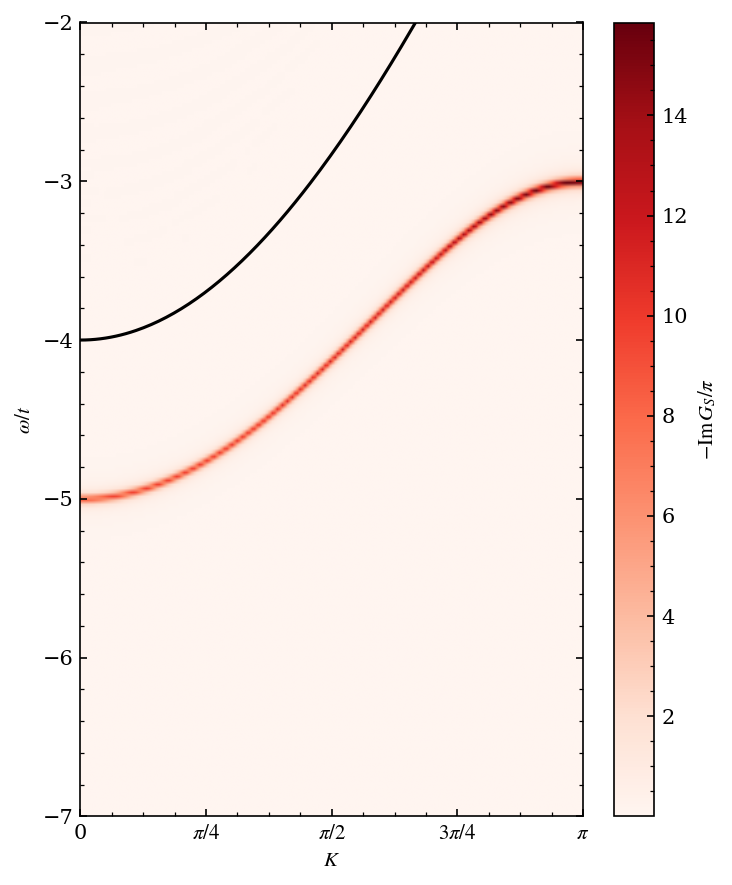

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(5, 6))

im = ax.imshow(
    spectral_2d,
    origin='lower',
    extent=[k_values[0], k_values[-1], omega_values[0], omega_values[-1]],
    aspect='auto',
    cmap='Reds',
    interpolation='bilinear',
)

ax.set_xlabel(r'$K$')
ax.set_ylabel(r'$\omega / t$')
plt.plot(k_values, -4*t_c*np.abs(np.cos(k_values/2)), color = "k", lw = 1.5)
# Nice k-axis ticks
ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 4))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: {0: '0', 1: r'$\pi/4$', 2: r'$\pi/2$', 3: r'$3\pi/4$', 4: r'$\pi$'}
    .get(round(x / (np.pi/4)), f'{x:.2f}')
))
ax.set_ylim(-7, -2)
fig.colorbar(im, ax=ax, label=r'$-\mathrm{Im}\,G_S / \pi$')
fig.tight_layout()
plt.show()

In [150]:
class RealSpaceMagneticPolaron:
    def __init__(self, t, J_0, J_e, s, gamma=1.0):
        self.t = float(t)
        self.J_0 = float(J_0)
        self.J_e = float(J_e)
        self.s = float(s)
        self.gamma = float(gamma)

    def denominator(self, z, K):
        z = np.asarray(z, dtype=np.complex128)
        K = np.asarray(K, dtype=float)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * self.s
        disc = alpha**2 - 4.0 * A_plus * A_minus
        sqrt_disc = np.sqrt(disc + 0j)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = np.where(np.abs(rho1) < np.abs(rho2), rho1, rho2)
        beta = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * (self.s - 1.0)
        g2 = (self.gamma * self.J_e)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        return z + 2.0 * self.t * np.cos(K) + 0.5 * self.J_e * self.s - Sigma

    def denominator_real_below_continuum(self, omega, K):
        """
        Evaluate D(omega, K) on the real axis, ASSUMING omega is below the
        spin-polaron continuum so disc > 0 and D is purely real.
        Returns a real float. Use this for brentq.
        """
        omega = float(omega)
        K = float(K)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * self.s
        disc = alpha**2 - 4.0 * A_plus * A_minus
        # Below continuum: disc is real and positive
        disc_real = disc.real
        if disc_real < 0:
            disc_real = 0.0  # at the edge
        sqrt_disc = np.sqrt(disc_real)
        # rho candidates (A_minus is complex but for real omega below continuum,
        # A+A- is real, so alpha^2 - 4A+A- is real, and rho is real)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = rho1 if abs(rho1) < abs(rho2) else rho2
        beta = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * (self.s - 1.0)
        g2 = (self.gamma * self.J_e)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        result = omega + 2.0 * self.t * np.cos(K) + 0.5 * self.J_e * self.s - Sigma
        return result.real

    def sp_continuum_edge(self, K):
        """
        Lower edge of the spin-polaron continuum at momentum K.
        This is where disc = alpha^2 - 4 A+ A- = 0.
        The continuum is the electron-magnon scattering states:
           E(K,q) = -2t cos(K-q) + 2 J0 s (1 - cos q) + Je s / 2
        Minimized over magnon momentum q.
        """
        K = float(K)
        q_grid = np.linspace(-np.pi, np.pi, 5000)
        E_vals = (-2.0 * self.t * np.cos(K - q_grid)
                  + 2.0 * self.J_0 * self.s * (1.0 - np.cos(q_grid))
                  + 0.5 * self.J_e * self.s)
        return np.min(E_vals)

    def G_minus(self, z, K):
        return 1.0 / self.denominator(z, K)

    def spectral_weight(self, K, omega, eta=2e-2):
        z = omega + 1j * eta
        return -np.imag(self.G_minus(z, K)) / np.pi


Extracting spin polaron band for Je=-0.5...
  Found poles at 1/500 k-points
  Missing poles near k/pi = [-1.    -0.996 -0.992 -0.988 -0.984] ...
  Min binding energy: 0.000000
  Max binding energy: 0.000000
Saved plot.
Saved data.


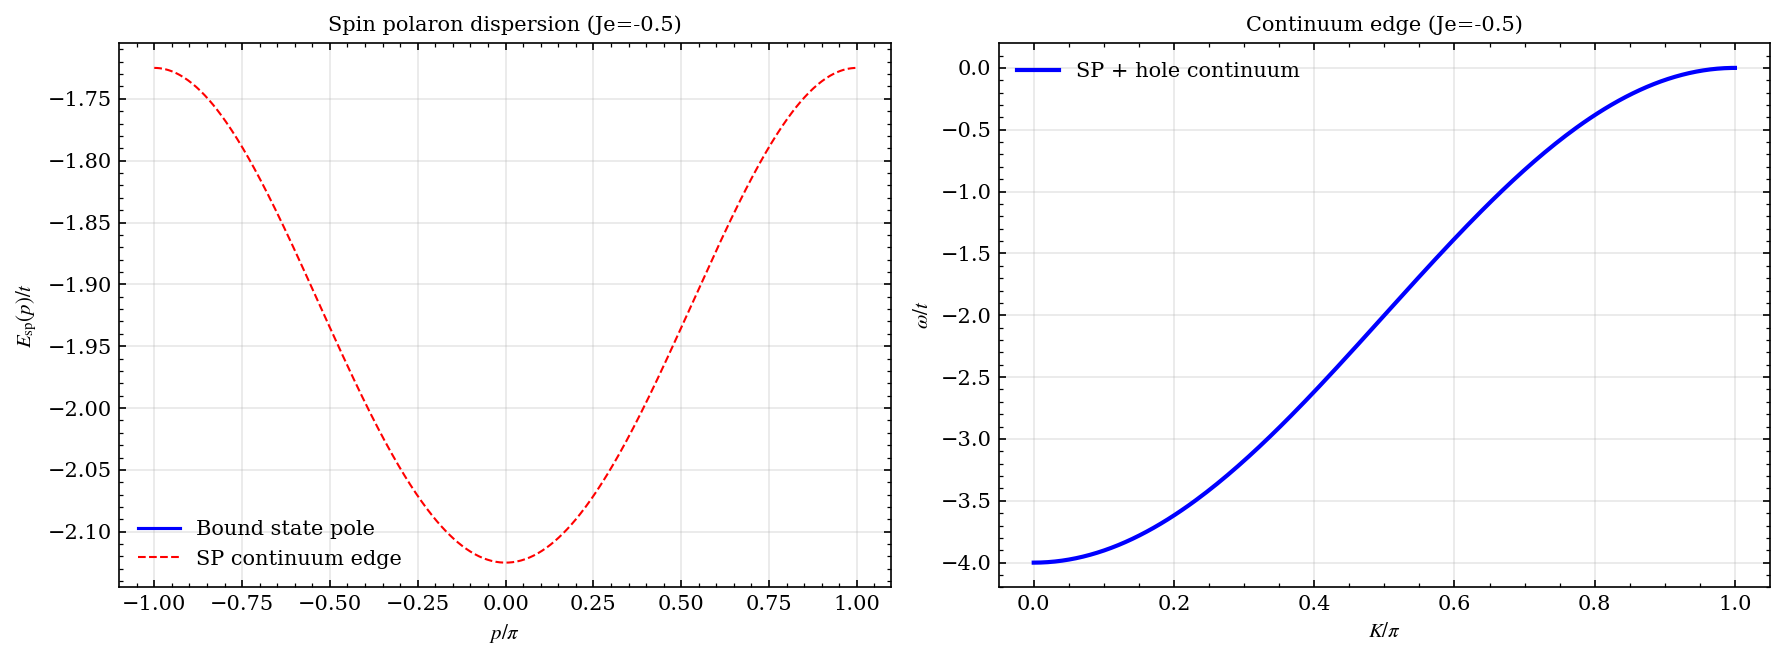

In [151]:
def extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0, padding=1e-8):
    """
    Exact pole extraction.
    1. For each p, compute the spin-polaron continuum edge E_cont(p).
    2. Search for the pole of D(omega, p) = 0 in [wmin, E_cont(p) - padding].
    3. Use a coarse scan + brentq refinement.
    """
    n_p = len(p_grid)
    E_sp = np.full(n_p, np.nan, dtype=float)

    # Step 1: continuum edges (vectorized over q, looped over p)
    E_cont = np.array([pol.sp_continuum_edge(p) for p in p_grid])

    # Step 2: for each p, find the pole below E_cont
    for j, p in enumerate(p_grid):
        w_lo = wmin
        w_hi = E_cont[j] - padding

        if w_hi <= w_lo:
            continue

        # Coarse scan
        n_scan = 2000
        w_scan = np.linspace(w_lo, w_hi, n_scan)
        D_scan = np.array([pol.denominator_real_below_continuum(w, p) for w in w_scan])

        # Find sign changes
        sign_changes = np.where(np.diff(np.signbit(D_scan)))[0]

        if len(sign_changes) == 0:
            # Adaptive refinement near the continuum edge
            # Use geometrically spaced points to resolve arbitrarily small binding
            found_fine = False
            for depth in range(8):  # each level 10x finer
                width = 0.5 * (0.1 ** depth)
                w_lo_fine = max(w_lo, w_hi - width)
                if w_hi - w_lo_fine < 1e-15:
                    break
                w_scan_fine = np.linspace(w_lo_fine, w_hi, 2000)
                D_scan_fine = np.array([pol.denominator_real_below_continuum(w, p)
                                        for w in w_scan_fine])
                sign_changes_fine = np.where(np.diff(np.signbit(D_scan_fine)))[0]
                if len(sign_changes_fine) > 0:
                    roots = []
                    for i in sign_changes_fine:
                        try:
                            root = brentq(
                                lambda w: pol.denominator_real_below_continuum(w, p),
                                w_scan_fine[i], w_scan_fine[i+1], xtol=1e-14)
                            roots.append(root)
                        except:
                            pass
                    if roots:
                        E_sp[j] = min(roots)
                        found_fine = True
                    break
            if not found_fine:
                continue

        # Refine all brackets, take the lowest
        roots = []
        for i in sign_changes:
            try:
                root = brentq(lambda w: pol.denominator_real_below_continuum(w, p),
                              w_scan[i], w_scan[i+1], xtol=1e-14)
                roots.append(root)
            except:
                pass
        if roots:
            E_sp[j] = min(roots)

    return E_sp, E_cont


def wrap_to_bz(x):
    return (x + np.pi) % (2.0 * np.pi) - np.pi


def spin_polaron_hole_continuum(
    K_ex_grid,
    p_grid,
    E_sp,
    t_v,
    *,
    Jv=0.0,
    s=0.5,
):
    """
    Asymptotic spin-polaron + hole continuum.

    Momentum convention:
        p_sp + k_h = K_factor * K_ex

    Usually:
        K_factor = 1.0   if K_ex is the physical total momentum K
        K_factor = 2.0   if your solver variable is half the physical momentum

    Energy:
        E_cont(K) = min_p [
            E_sp(p)
            + E_h(K - p)
            + Jv*s/2
        ]

    This includes the far-separated hole-FM longitudinal shift.
    It does NOT include the local hole-magnon correction -Jv/2 delta_{m,R},
    because that is an interaction inside the full two-coordinate problem,
    not an asymptotic continuum shift.
    """
    K_ex_grid = np.asarray(K_ex_grid, dtype=float)
    p_grid = np.asarray(p_grid, dtype=float)
    E_sp = np.asarray(E_sp, dtype=float)

    valid = np.isfinite(E_sp)
    if not np.any(valid):
        raise RuntimeError("No valid spin-polaron poles in E_sp.")

    p_valid = p_grid[valid]
    E_valid = E_sp[valid]

    k_h = wrap_to_bz(K_ex_grid[:, None] - p_valid[None, :])

    E_h = -2.0 * t_v * np.cos(k_h) + 0.5 * Jv * s

    E_mat = E_valid[None, :] + E_h

    idx = np.argmin(E_mat, axis=1)
    E_cont = E_mat[np.arange(K_ex_grid.size), idx]
    p_star = p_valid[idx]
    k_h_star = k_h[np.arange(K_ex_grid.size), idx]

    return E_cont, p_star, k_h_star


# =====================================================
# Parameters — change Je here
# =====================================================

pol = RealSpaceMagneticPolaron(t=t_c, J_0=J0, J_e=Je, s=s, gamma=gamma)

# 1) Exact spin-polaron dispersion
p_grid = np.linspace(-np.pi, np.pi, 500, endpoint=False)
print(f"Extracting spin polaron band for Je={Je}...")
E_sp, E_sp_cont = extract_lowest_spin_polaron_band(pol, p_grid, wmin=omega_values[0])

n_valid = np.sum(~np.isnan(E_sp))
n_total = len(E_sp)
print(f"  Found poles at {n_valid}/{n_total} k-points")
if n_valid < n_total:
    n_missing = n_total - n_valid
    missing_k = p_grid[np.isnan(E_sp)]
    print(f"  Missing poles near k/pi = {missing_k[:5]/np.pi} ...")

# Check binding energy
binding = E_sp_cont - E_sp
print(f"  Min binding energy: {np.nanmin(binding):.6f}")
print(f"  Max binding energy: {np.nanmax(binding):.6f}")

# 2) Build the sp + hole continuum
K_ex = k_values
E_cont, p_star, k_h_star = spin_polaron_hole_continuum(
    K_ex_grid=K_ex,
    p_grid=p_grid,
    E_sp=E_sp,
    t_v=t_v,
    Jv=-Jv,
    s=s,
)

# 3) Plot spin-polaron band + continuum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(p_grid/np.pi, E_sp, 'b-', lw=1.5, label='Bound state pole')
ax1.plot(p_grid/np.pi, E_sp_cont, 'r--', lw=1, label='SP continuum edge')
ax1.set_xlabel(r'$p/\pi$')
ax1.set_ylabel(r'$E_{\rm sp}(p)/t$')
ax1.set_title(f'Spin polaron dispersion (Je={Je})')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(K_ex/np.pi, E_cont, 'b-', lw=2, label='SP + hole continuum')
ax2.set_xlabel(r'$K/\pi$')
ax2.set_ylabel(r'$\omega/t$')
ax2.set_title(f'Continuum edge (Je={Je})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sp_continuum_Je_{:.1f}.png'.format(Je), dpi=200, bbox_inches='tight')
print(f"Saved plot.")

# Save data
np.savez('sp_continuum_data_Je_{:.1f}.npz'.format(Je),
         p_grid=p_grid, E_sp=E_sp, E_sp_cont=E_sp_cont,
         K_ex=K_ex, E_cont=E_cont, p_star=p_star, k_h_star=k_h_star)
print("Saved data.")
plt.show()

In [152]:
import numpy as np
import matplotlib.pyplot as plt

def wrap_to_pi(x):
    return (x + np.pi) % (2*np.pi) - np.pi

def exciton_bound_energy(k, t_c, t_v, U, Je=0.0, s=0.5):
    """
    Exact exciton bound-state dispersion in the reduced momentum variable k,
    where the formula depends on cos(k).

    k can be scalar or array.
    """
    A = t_c**2 + t_v**2 + 2.0*t_c*t_v*np.cos(k)
    E = -np.sqrt(U**2 + 4.0*A)   # lower / bound branch
    return E



def magnon_dispersion(q, J0, s, Je):
    """
    Exact 1D FM magnon dispersion in the same energy convention as your solver.
    """
    return 2.0*J0*s*(1.0 - np.cos(q)) + Je*s/2

def exciton_magnon_continuum(K_grid, t_c, t_v, U, J0, s, Je=0.0,
                             nq=2002):
    """
    Exciton + magnon continuum in the exciton-magnon solver convention.

    K_grid: solver momentum variable K in [0, pi]
    q: physical magnon momentum in [-pi, pi)
    Exciton reduced momentum is k_X = K - q, so cos( k_X) = cos(K - q).

    Returns:
      E_low(K), E_high(K), q_star_low(K), q_star_high(K), E_all(K,q)
    """
    K_grid = np.asarray(K_grid, dtype=float)
    q_grid = np.linspace(-np.pi, np.pi, nq, endpoint=False)

    # Broadcast over K and q
    K2 = K_grid[:, None]
    Q  = q_grid[None, :]

    # Exciton reduced momentum in your exact formula
    kX = K2 - Q

    EX = exciton_bound_energy(
        kX, t_c=t_c, t_v=t_v, U=U, Je=Je, s=s
    )
    WM = magnon_dispersion(Q, J0=J0, s=s, Je=Je)

    E_all = EX + WM

    idx_low  = np.argmin(E_all, axis=1)
    idx_high = np.argmax(E_all, axis=1)

    E_low  = E_all[np.arange(len(K_grid)), idx_low]
    E_high = E_all[np.arange(len(K_grid)), idx_high]

    q_star_low  = q_grid[idx_low]
    q_star_high = q_grid[idx_high]

    return E_low, E_high, q_star_low, q_star_high, q_grid, E_all

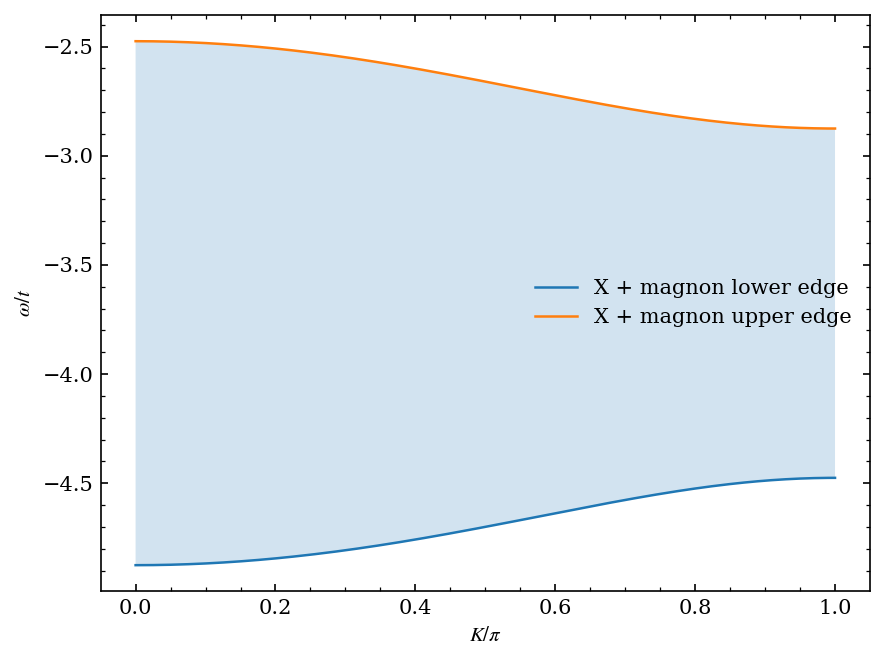

In [153]:
# Parameters


K_grid = k_values

E_low, E_high, q_low, q_high, q_grid, E_all = exciton_magnon_continuum(
    K_grid,
    t_c=t_c,
    t_v=t_v,
    U=-U,
    J0=J0,
    s=s,
    Je=-Je,
    nq=2002,
)

# Plot edges
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(K_grid/np.pi, E_low,  label='X + magnon lower edge')
ax.plot(K_grid/np.pi, E_high, label='X + magnon upper edge')
ax.fill_between(K_grid/np.pi, E_low, E_high, alpha=0.2)
ax.set_xlabel(r'$K/\pi$')
ax.set_ylabel(r'$\omega/t$')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
pol = RealSpaceMagneticPolaron(t=t_c, J_0=J0, J_e=-Je, s=s, gamma=gamma)

# 1) Exact spin-polaron dispersion
p_grid = np.linspace(-np.pi, np.pi, 400, endpoint=False)
print(f"Extracting spin polaron band for Je={Je}...")
E_sp, E_sp_cont = extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0*t_c)

n_valid = np.sum(~np.isnan(E_sp))
n_total = len(E_sp)
print(f"  Found poles at {n_valid}/{n_total} k-points")
if n_valid < n_total:
    n_missing = n_total - n_valid
    missing_k = p_grid[np.isnan(E_sp)]
    print(f"  Missing poles near k/pi = {missing_k[:5]/np.pi} ...")

# Check binding energy
binding = E_sp_cont - E_sp
print(f"  Min binding energy: {np.nanmin(binding):.6f}")
print(f"  Max binding energy: {np.nanmax(binding):.6f}")

# 2) Build the sp + hole continuum
K_ex = k_values
E_cont, p_star, k_h_star = spin_polaron_hole_continuum(
    K_ex_grid=K_ex,
    p_grid=p_grid,
    E_sp=E_sp,
    t_v=t_v,
    Jv=Jv,
    s=s,
)

Extracting spin polaron band for Je=-0.5...


/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:49: RuntimeWarning: divide by zero encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:49: RuntimeWarning: invalid value encountered in cdouble_scalars


In [ ]:
# Create the plot
fig, ax = plt.subplots(figsize=(5, 4))

# Plot as 2D image
im = ax.imshow(spectral_2d, 
               extent=[0, 1, omega_values[0]/t_c, omega_values[-1]/t_c],
               aspect='auto',
               origin='lower',
               cmap='Reds',  # inverted grayscale like the figure
                ) 

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\rho_\downarrow(k,\omega)$')

#plt.plot(k_values/np.pi,-5.2-0.7*np.cos(2*k_values) )
t_c=t_v =1
ax.plot(k_values/np.pi, E_cont, label="spin-polaron+hole", lw=1.5)
ax.plot(K_grid/np.pi, E_low , color='g', lw=1.5)
#plt.plot(k_values/np.pi, min_values_abs)
# Add dashed line at omega=0 (or wherever appropriate)
#ax.axhline(-0.75, ls='--', c='grey', lw=2, alpha=0.5)
#plt.plot(k_values/np.pi, q_min_array + E_min_array)
#plt.plot(k_values/np.pi, -4*np.abs(t_c*np.cos(k_values)))
plt.plot(k_values/np.pi, -4*t_c*np.abs(np.cos(k_values/2)), color = "k", lw=1.5)
#plt.ylim(-4.4,-4.2)
# Labels
ax.set_xlabel(r'$k/\pi$')
ax.set_ylabel(r'$\omega/t$')
#ax.text(0.95, 0.05, '(b)', transform=ax.transAxes, 
#        fontsize=12, verticalalignment='bottom', horizontalalignment='right')
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig('spectral_function_2d.png', dpi=200, bbox_inches='tight')
print("Plot saved to outputs/spectral_function_2d.png")
#ax.axhline(11,color='r', linestyle='--')
#ax.axhline(3,color='r', linestyle='--')
ax.set_ylim(-7, -2)
#ax.axhline(-15.5,color='g', linestyle='--')
#ax.axhline(-12.5,color='g', linestyle='--')
plt.show()

# change of basis to cross check with old code

In [23]:
def spectral_X_down(solver, K, omega, eta, R=0, Rsrc=0):
    z = omega + 1j*eta

    # column with S source
    GS_col = solver.solve(z, K, source="S", Rsrc=Rsrc)
    GSS   = solver.get_G_S(GS_col, R)
    GT0S  = solver.get_G_T0(GS_col, R)

    # column with T0 source
    GT0_col = solver.solve(z, K, source="T0", Rsrc=Rsrc)
    GST0   = solver.get_G_S(GT0_col, R)
    GT0T0  = solver.get_G_T0(GT0_col, R)

    GXX = 0.5 * (GSS - GST0 - GT0S + GT0T0)
    return -np.imag(GXX) / np.pi

def compute_column(args):
    i, k, omega_values, eta, params = args

    pid = os.getpid()
    solver = ExcitonMagnonSolver(**params)

    col = np.empty(len(omega_values), dtype=float)
    for j, w in enumerate(omega_values):
        col[j] = spectral_X_down(
            solver,
            K=k,
            omega=w,
            eta=eta,
            R=0,
            Rsrc=0,
        )

    return i, col, pid


tasks = [(i, k, omega_values, eta, params) for i, k in enumerate(k_values)]

cols = [None] * len(k_values)
pid_counts = Counter()

t0 = time.time()

with ProcessPoolExecutor(max_workers=n_workers) as ex:
    futures = [ex.submit(compute_column, task) for task in tasks]

    for done, fut in enumerate(as_completed(futures), 1):
        i, col, pid = fut.result()
        cols[i] = col
        pid_counts[pid] += 1

        if done % 10 == 0 or done == len(futures):
            print(
                f"Finished {done}/{len(tasks)} k-columns | "
                f"worker PIDs seen: {len(pid_counts)}/{n_workers} | "
                f"elapsed: {time.time() - t0:.1f}s",
                flush=True,
            )

spectral_2d = np.stack(cols, axis=1)

Finished 10/200 k-columns | worker PIDs seen: 10/28 | elapsed: 16.4s
Finished 20/200 k-columns | worker PIDs seen: 20/28 | elapsed: 16.5s
Finished 30/200 k-columns | worker PIDs seen: 28/28 | elapsed: 32.2s
Finished 40/200 k-columns | worker PIDs seen: 28/28 | elapsed: 32.4s
Finished 50/200 k-columns | worker PIDs seen: 28/28 | elapsed: 32.5s
Finished 60/200 k-columns | worker PIDs seen: 28/28 | elapsed: 48.3s
Finished 70/200 k-columns | worker PIDs seen: 28/28 | elapsed: 48.4s
Finished 80/200 k-columns | worker PIDs seen: 28/28 | elapsed: 48.6s
Finished 90/200 k-columns | worker PIDs seen: 28/28 | elapsed: 64.1s
Finished 100/200 k-columns | worker PIDs seen: 28/28 | elapsed: 64.4s
Finished 110/200 k-columns | worker PIDs seen: 28/28 | elapsed: 64.7s
Finished 120/200 k-columns | worker PIDs seen: 28/28 | elapsed: 80.1s
Finished 130/200 k-columns | worker PIDs seen: 28/28 | elapsed: 80.4s
Finished 140/200 k-columns | worker PIDs seen: 28/28 | elapsed: 80.9s
Finished 150/200 k-columns | 

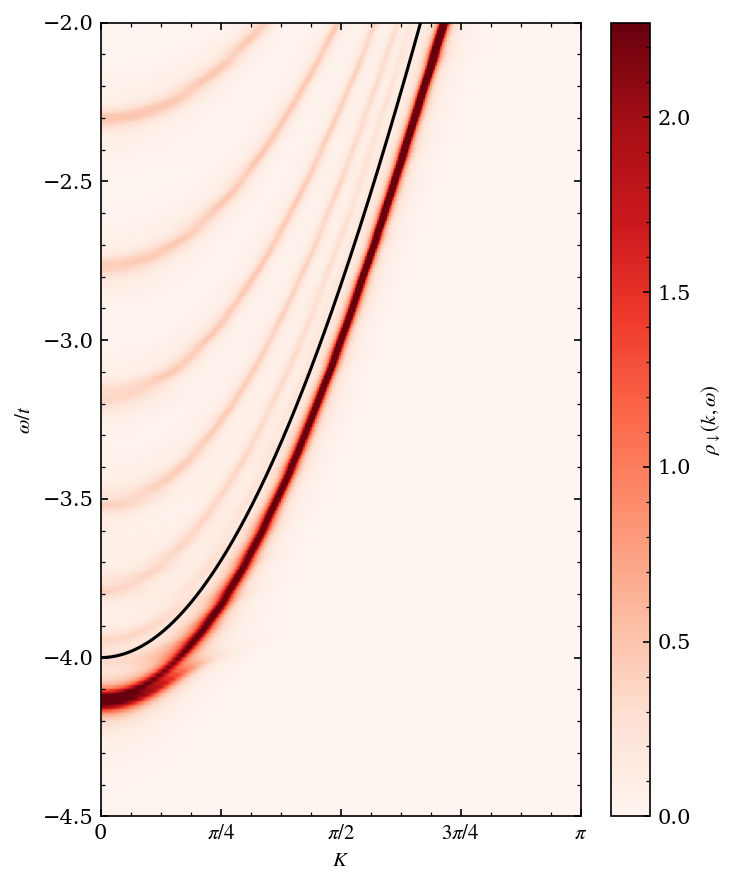

In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(5, 6))

im = ax.imshow(
    spectral_2d,
    origin='lower',
    extent=[k_values[0], k_values[-1], omega_values[0], omega_values[-1]],
    aspect='auto',
    cmap='Reds',
    vmin=0,
    vmax=np.percentile(spectral_2d, 99))  # clip at 99th percentile for better contrast

ax.set_xlabel(r'$K$')
ax.set_ylabel(r'$\omega / t$')
plt.plot(k_values, -4*t_c*np.abs(np.cos(k_values/2)), color = "k", lw = 1.5)
# Nice k-axis ticks
ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 4))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: {0: '0', 1: r'$\pi/4$', 2: r'$\pi/2$', 3: r'$3\pi/4$', 4: r'$\pi$'}
    .get(round(x / (np.pi/4)), f'{x:.2f}')
))
ax.set_ylim(-4.5, -2)
fig.colorbar(im, ax=ax, label=r'$\rho_\downarrow(k,\omega)$')
fig.tight_layout()
plt.show()